# Pre-analysis: global program per network, local views, and BDM

This notebook is a read-only audit and explanation of the compression and BDM observables in the degree-five study. It does not recompute or modify the released records.

The central question is:

> Does the current Section 12 program describe one whole network, or is it accidentally built pattern by pattern?

We answer this by inspecting the actual compiler, then use an exact toy example only to explain what would be wrong if one isolated local pair were mistaken for the complete model.


In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'font.size': 11})

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd() / 'doppel-challenge'
if not (ROOT / 'results/joint_degree5_v2').exists():
    ROOT = Path('/Users/alberto/Documents/projects/CausalBool/doppel-challenge')
RESULTS = ROOT / 'results/joint_degree5_v2'
ANALYSIS = RESULTS / 'analysis'

parent_release = json.loads((RESULTS / 'scientific_release.json').read_text())
analysis = json.loads((ANALYSIS / 'analysis.json').read_text())
summary = json.loads((RESULTS / 'main/summary.json').read_text())
effects = pd.read_csv(ANALYSIS / 'effect_rows.csv')
groups = pd.read_csv(ANALYSIS / 'group_summary.csv')
bases = pd.read_csv(ANALYSIS / 'base_catalogue_rows.csv')

print('Read-only inputs loaded.')
print('Parent scientific release ready:', parent_release['release_ready'])
print('Network records:', parent_release['n_accepted_networks'])
print('Catalogue definitions:', len(summary['catalogues']))
print('Nonempty base catalogues in paired analysis:', len(bases))
print('Effect rows:', len(effects))


Read-only inputs loaded.
Parent scientific release ready: True
Network records: 21380
Catalogue definitions: 480
Nonempty base catalogues in paired analysis: 479
Effect rows: 21140


## 1. Four different objects must not be confused

For a Boolean network with N nodes, the exhaustive one-step output repertoire is a binary matrix with 2**N rows and N columns. Its raw binary length is:

raw bits = N * 2**N

There are several related but different objects:

1. A local index entry for one output pattern: one decimal value and its Sumandos/position expression.
2. A global DecimalRepertoire/Sumandos representation returned by the whole-behaviour owner. The owner returns the complete collection of output-pattern representations in one network-level result.
3. The current Section 12 shared executable program: one symbolic decision DAG per network, with shared Boolean nodes and one ordered output reference per network node.

The current Section 12 compiler constructs object 3 once per network. Its schema export is an explanatory view of that same program, not a collection of independent network models. A local entry can be shorter than the raw matrix while still failing to specify the rest of the matrix, which is why the toy warning below is useful—but it is not a description of the current compiler.


In [5]:
N = 3
raw_bits = N * (2 ** N)
decimal_repertoire = [0]
sumandos = [1, 5]

def lsb_bits(value, width):
    return ''.join(str((value >> bit) & 1) for bit in range(width))

toy_local = pd.DataFrame({
    'object': ['DecimalRepertoire value', 'Sumando 1', 'Sumando 5'],
    'decimal value': [0, 1, 5],
    '3-bit LSB-first representation': [lsb_bits(0, 3), lsb_bits(1, 3), lsb_bits(5, 3)],
})
display(toy_local)
display(pd.DataFrame({
    'quantity': ['raw output matrix', 'local [DecimalRepertoire, Sumandos] payload'],
    'bits': [raw_bits, 3 * (len(decimal_repertoire) + len(sumandos))],
    'interpretation': [
        'all 8 rows x 3 output bits',
        'only the displayed integers, assuming fixed 3-bit fields'
    ]
}))
print('The local payload is 9 bits and the raw matrix is 24 bits.')
print('That inequality is correct, but it does not yet prove whole-repertoire compression.')


,object,decimal value,3-bit LSB-first representation
0,DecimalRepertoire value,0,000
1,Sumando 1,1,100
2,Sumando 5,5,101


,quantity,bits,interpretation
0,raw output matrix,24,all 8 rows x 3 output bits
1,"local [DecimalRepertoire, Sumandos] payload",9,"only the displayed integers, assuming fixed 3-..."


The local payload is 9 bits and the raw matrix is 24 bits.
That inequality is correct, but it does not yet prove whole-repertoire compression.


## 2. A toy warning about an incomplete local entry

This is deliberately not the Section 12 algorithm. Here are two different complete 8-row output repertoires. Both contain pattern 000 at exactly positions 1 and 5, so both produce the same isolated local pair:

DecimalRepertoire = [0], Sumandos = [1, 5].

But the remaining six rows differ. Therefore the local pair cannot distinguish the two full repertoires. This is an exact ambiguity proof, not an argument about practical compression.

The actual Section 12 method avoids this ambiguity by constructing a different global program for each network. The two repertoires below are only a proof that the isolated local pair is not sufficient by itself.


,complete repertoire,positions for pattern 000,global index object,same local pair?,same complete repertoire?
0,A,"[1, 5]","{4: [0], 0: [1, 5], 2: [2], 6: [3], 7: [4], 3:...",True,False
1,B,"[1, 5]","{7: [0], 0: [1, 5], 2: [2], 6: [3], 4: [4], 3:...",True,False


A and B share the local pair but are different full behaviours: True
A global index: {4: [0], 0: [1, 5], 2: [2], 6: [3], 7: [4], 3: [6], 5: [7]}
B global index: {7: [0], 0: [1, 5], 2: [2], 6: [3], 4: [4], 3: [6], 5: [7]}


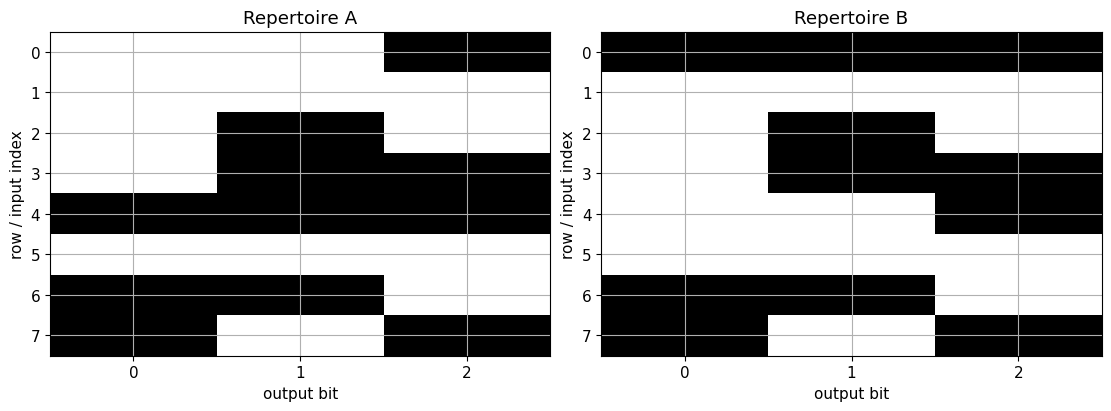

In [6]:
A = ['001', '000', '010', '011', '111', '000', '110', '101']
B = ['111', '000', '010', '011', '001', '000', '110', '101']
assert [i for i, row in enumerate(A) if row == '000'] == [1, 5]
assert [i for i, row in enumerate(B) if row == '000'] == [1, 5]

def global_index(rows):
    result = {}
    for position, row in enumerate(rows):
        decimal = sum(int(bit) << j for j, bit in enumerate(row))
        result.setdefault(decimal, []).append(position)
    return result

index_A = global_index(A)
index_B = global_index(B)
comparison = pd.DataFrame({
    'complete repertoire': ['A', 'B'],
    'positions for pattern 000': [[i for i, row in enumerate(A) if row == '000'],
                                   [i for i, row in enumerate(B) if row == '000']],
    'global index object': [index_A, index_B],
    'same local pair?': [True, True],
    'same complete repertoire?': [A == B, A == B],
})
display(comparison)
print('A and B share the local pair but are different full behaviours:', A != B)
print('A global index:', index_A)
print('B global index:', index_B)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, rows, title in zip(axes, [A, B], ['Repertoire A', 'Repertoire B']):
    matrix = np.array([[int(x) for x in row] for row in rows])
    ax.imshow(matrix, cmap='gray_r', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('output bit')
    ax.set_ylabel('row / input index')
    ax.set_yticks(range(8))
    ax.set_xticks(range(3))
plt.show()


### The exact correction—and its relation to our method

The statement 'the pair is 9 bits, therefore the whole repertoire is compressed to 9 bits' is valid only after the pair has been produced by a global construction proven to reproduce every row.

If someone computes a pair separately for each output pattern and adds those lengths, the measured object has changed. It is a collection of local descriptions, with repeated keys, boundaries, and possibly repeated framing. It can be larger than the raw matrix. It is not the same as one global flat index object. Section 12 does not do that: it calls compile_repertoire_program(net) once and shares the resulting decision nodes across all output functions.

The input repertoire is implicit in this framework. That removes the need to encode the ordered list of all inputs. It does not remove the need to encode enough global information to determine the output associated with every implicit input.


## 3. What the current exact records measure

The released records contain two separate length observables:

- raw_bit_length: N * 2**N, the exhaustive binary output matrix.
- program_bit_length: the complete shared executable representation under shared_repertoire_program_v1.

The current program is not just a naked visual list of integers. Its recorded length is composed from the codec's decision count, decision records, and output references. This is appropriate for a reproducible executable description, but it must be named honestly. It is an algorithmic description length for this codec, not universal Kolmogorov complexity and not automatically identical to a hypothetical naked DecimalRepertoire/Sumandos payload.


In [7]:
empty = [c for c in summary['catalogues'] if len(c.get('effects', [])) == 0]
display(pd.DataFrame([{
    'base_id': c['base_id'], 'family': c['family'], 'N': c['n'], 'kind': c['kind'],
    'admissible': c['n_admissible'], 'excluded': c['n_excluded'],
    'nonidentity effects': c['n_nonidentity']
} for c in empty]))

denominators = pd.DataFrame({
    'quantity': ['accepted networks', 'catalogue definitions', 'nonempty base catalogues', 'paired effect rows'],
    'count': [parent_release['n_accepted_networks'], len(summary['catalogues']), len(bases), len(effects)],
    'meaning': [
        'verified exact network records',
        'all declared family/N/kind/base catalogue entries',
        'catalogues contributing at least one paired effect',
        'non-identity perturbations with paired program/BDM/dynamics values'
    ]
})
display(denominators)


,base_id,family,N,kind,admissible,excluded,nonidentity effects
0,modular_n8_s15,modular,8,EDGE_REMOVE,1,8,0


,quantity,count,meaning
0,accepted networks,21380,verified exact network records
1,catalogue definitions,480,all declared family/N/kind/base catalogue entries
2,nonempty base catalogues,479,catalogues contributing at least one paired ef...
3,paired effect rows,21140,non-identity perturbations with paired program...


## 4. Positions materialized and digest

These fields answer different questions.

- Positions materialized is an implementation/provenance flag. False means the compiler did not build an explicit list of all output positions while constructing the program. The exact validation owner can still materialize the exhaustive output matrix afterward to verify the decoder. Avoiding Python-side unfolding is not the same as proving that no internal owner step materialized anything.
- Digest is a SHA-256 identity of canonical record content. Equal canonical records have equal digests; a digest is not a length and is not a complexity value. It detects accidental changes, duplicates, and mismatched representations.


In [8]:
sample = effects.iloc[0]
network_path = RESULTS / 'main/networks' / f"{sample['network_sha256']}.json"
record = json.loads(network_path.read_text())
compression = record['compression']

fields = [
    ('network size N', compression['network_size']),
    ('raw bit length', compression['raw_bit_length']),
    ('program bit length', compression['program_bit_length']),
    ('decision count bits', compression['decision_count_bits']),
    ('decision record bits', compression['decision_record_bits']),
    ('output reference bits', compression['output_reference_bits']),
    ('stored bit length incl. padding', compression['stored_bit_length']),
    ('padding bits', compression['padding_bits']),
    ('compiler materializes positions', compression['compiler_materializes_positions']),
    ('validation materializes output matrix', compression['validation_materializes_output_matrix']),
    ('validation scope', compression['validation_scope']),
    ('record digest', record['sha256']),
]
display(pd.DataFrame(fields, columns=['field', 'value']))

accounted = compression['decision_count_bits'] + compression['decision_record_bits'] + compression['output_reference_bits']
print('decision count + decision records + output references =', accounted, 'bits')
print('recorded program_bit_length =', compression['program_bit_length'], 'bits')
print('program is shorter than raw for this row:', compression['program_bit_length'] < compression['raw_bit_length'])
print('sample BDM value:', record['compression']['bdm_original_output']['value'])
print('BDM is a separate model estimate, not a bit count.')


,field,value
0,network size N,8
1,raw bit length,2048
2,program bit length,283
3,decision count bits,9
4,decision record bits,234
5,output reference bits,40
6,stored bit length incl. padding,288
7,padding bits,5
8,compiler materializes positions,False
9,validation materializes output matrix,True


decision count + decision records + output references = 283 bits
recorded program_bit_length = 283 bits
program is shorter than raw for this row: True
sample BDM value: 512.0268537317725
BDM is a separate model estimate, not a bit count.


## 5. Visual check: raw versus the current complete program

This is the meaningful comparison for the current records: the raw exhaustive binary matrix against the complete executable program length. The horizontal line at 100% is raw length. Values below it mean the recorded program is shorter than the raw binary matrix.

This plot must not be labelled naked flat DecimalRepertoire/Sumandos length unless that separate representation has been constructed globally and decoded exhaustively.


/var/folders/54/tt8_6d357691t8wwz7yxv9880000gn/T/ipykernel_55123/1843261961.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)


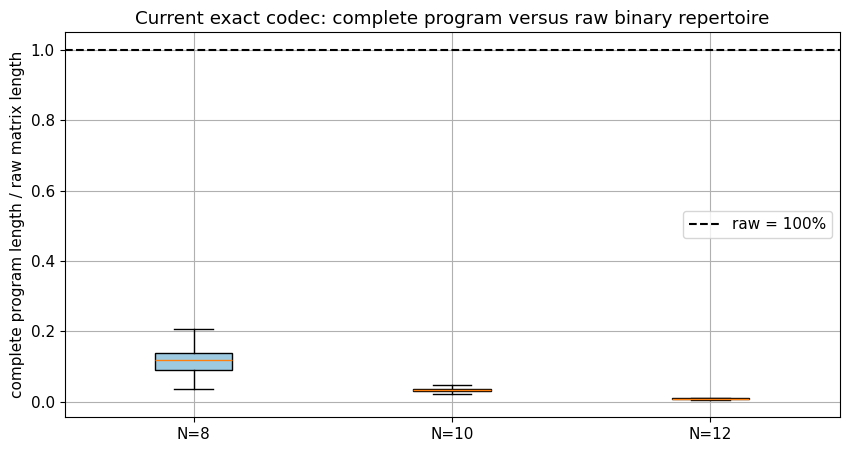

All effect rows have program_ratio < 1: True
Mean ratio: 0.03794130650727539
Median ratio: 0.02626953125


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [effects.loc[effects['n'] == n, 'program_ratio'].to_numpy() for n in sorted(effects['n'].unique())]
labels = [f'N={n}' for n in sorted(effects['n'].unique())]
bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#9ecae1', '#6baed6', '#2171b5']):
    patch.set_facecolor(color)
ax.axhline(1.0, color='black', linestyle='--', label='raw = 100%')
ax.set_ylabel('complete program length / raw matrix length')
ax.set_title('Current exact codec: complete program versus raw binary repertoire')
ax.legend()
plt.show()

print('All effect rows have program_ratio < 1:', bool((effects['program_ratio'] < 1).all()))
print('Mean ratio:', effects['program_ratio'].mean())
print('Median ratio:', effects['program_ratio'].median())


## 6. BDM comparison: related question, different observable

BDM estimates a description cost from a block-decomposition model. Here it is computed on the original output matrix with the recorded pybdm 0.1.0 provenance. It is not a binary serialization length.

Therefore:

- program bits and BDM units can be plotted together as paired changes;
- their numerical scales should not be merged;
- a weak correlation is not a failure of arithmetic, because the estimators use different models;
- a strong correlation would still be an empirical association, not proof of equality or universal Kolmogorov complexity.


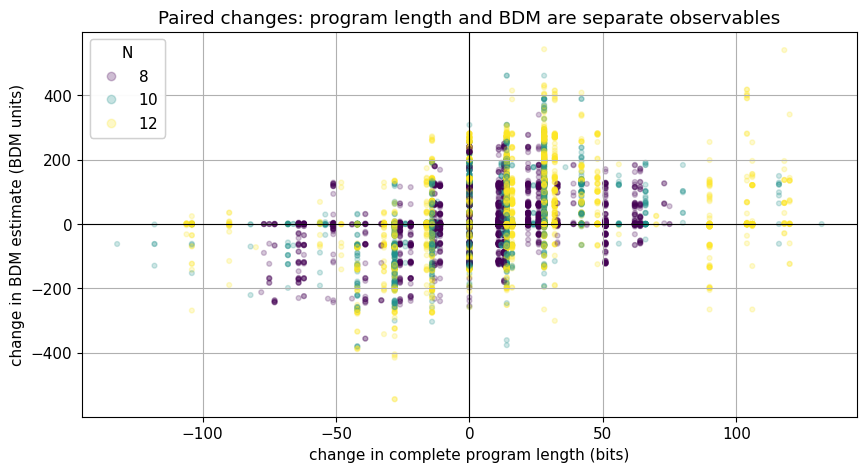

,association,Spearman rho,interpretation
0,program change vs BDM change,0.223369,different description estimators; descriptive ...
1,program change vs total variation,0.070224,program-length change is not a direct distribu...
2,BDM change vs total variation,0.065806,BDM and dynamics measure different properties


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(effects['delta_program_bits'], effects['delta_bdm'],
                     c=effects['n'], cmap='viridis', alpha=0.22, s=12)
ax.axvline(0, color='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('change in complete program length (bits)')
ax.set_ylabel('change in BDM estimate (BDM units)')
ax.set_title('Paired changes: program length and BDM are separate observables')
legend = ax.legend(*scatter.legend_elements(), title='N', loc='best')
ax.add_artist(legend)
plt.show()

o = analysis['overall']
display(pd.DataFrame({
    'association': ['program change vs BDM change',
                    'program change vs total variation',
                    'BDM change vs total variation'],
    'Spearman rho': [o['spearman_delta_program_vs_delta_bdm'],
                     o['spearman_delta_program_vs_total_variation'],
                     o['spearman_delta_bdm_vs_total_variation']],
    'interpretation': [
        'different description estimators; descriptive association only',
        'program-length change is not a direct distribution distance',
        'BDM and dynamics measure different properties'
    ]
}))


## 7. Direct audit of the actual Section 12 construction

This cell uses one real released network. It constructs exactly one symbolic program, inspects its shared node graph and ordered output references, and then decodes all implicit input rows only for verification. The schema counts are views of the same program.


In [11]:
from doppel_challenge.adapters import Network
from doppel_challenge.repertoire_program import (
    compile_repertoire_program, iter_output_rows, export_output_schemata, program_metadata
)

case = record['network']
network = Network(case['network_size'], case['cm'], case['dyn'], case['params'])
global_program = compile_repertoire_program(network)
global_metadata = program_metadata(global_program)
all_rows_for_verification = list(iter_output_rows(global_program))
schema_counts = [len(export_output_schemata(global_program, j)) for j in range(network.n)]

audit = pd.DataFrame({
    'quantity': [
        'network models constructed', 'shared decision nodes', 'ordered output references',
        'decoded rows for verification', 'expected rows', 'schema views (one per output bit)'
    ],
    'value': [
        1, len(global_program.nodes), len(global_program.outputs),
        len(all_rows_for_verification), 2 ** network.n, schema_counts
    ]
})
display(audit)
print('One program per network: PASS')
print('Shared program digest agrees with the released record:',
      global_metadata['canonical_program_sha256'] == compression['canonical_program_sha256'])
print('Compiler enumerates states:', global_metadata['compiler_enumerates_states'])
print('Compiler materializes positions:', global_metadata['compiler_materializes_positions'])
print('Exhaustive row verification:', len(all_rows_for_verification) == 2 ** network.n)
assert len(global_program.outputs) == network.n
assert len(all_rows_for_verification) == 2 ** network.n
assert global_metadata['canonical_program_sha256'] == compression['canonical_program_sha256']


,quantity,value
0,network models constructed,1
1,shared decision nodes,18
2,ordered output references,8
3,decoded rows for verification,256
4,expected rows,256
5,schema views (one per output bit),"[8, 1, 1, 1, 1, 2, 1, 1]"


One program per network: PASS
Shared program digest agrees with the released record: True
Compiler enumerates states: False
Compiler materializes positions: False
Exhaustive row verification: True


## 8. Conclusions

1. The nine-bit toy pair is smaller than the 24-bit raw matrix, but by itself it describes only the positions of 000. It is not a complete description of the eight-row repertoire.
2. That toy warning is not a description of our Section 12 compiler. Section 12 constructs one global symbolic program for each network, with shared nodes and multiple output references.
3. The whole-behaviour DecimalRepertoire/Sumandos owner is also called once per network. Its returned pattern representations form one network-level result; they are not separate network models.
4. Raw comparison is valid when both sides are compatible binary description lengths. In the current records, raw_bit_length is the binary matrix length and program_bit_length is the complete codec program length.
5. The earlier surprising plot in which a purported compressed form exceeded raw would indicate that a different object was plotted—such as local entries added together, framing, or decoder overhead—not that the verified global Section 12 program had been constructed pattern by pattern.
6. positions materialized describes execution strategy; digest identifies canonical record content. Neither is a complexity value.
7. BDM belongs in a separate comparison panel and must retain its implementation, shape, padding, and dependency provenance.

The correct next comparison is therefore: global DecimalRepertoire/Sumandos representation versus global symbolic program versus raw matrix, all decoded and verified against the same complete network behaviour.